Small example for using the plotting function.

*Use ```%matplotlib widget``` for the animated plot at the end! (here not used for the automatic github testing)*

In [8]:
import numpy as np
import sparrowpy as sp
import matplotlib.pyplot as plt
import pyfar as pf
import spharpy

%matplotlib widget

In [9]:
# boundary definitions by the right hand rule
boundaries = (
    np.array(
        [
            [  # ground plane
                [0, 0, 0],
                [1, 0, 0],
                [1, 1, 0],
                [0, 1, 0],
            ],
            [  # wall
                [1, 0, 0],
                [1, 1, 0],
                [1, 1, 1],
                [1, 0, 1],
            ],
        ],
    )
    * 2
)

Plot of static data on boundaries.

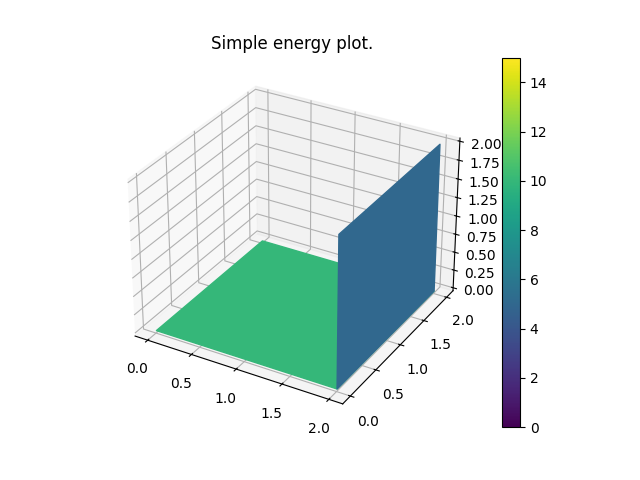

In [10]:
energy = np.array([10.0, 5.0])
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
sp.plot.polygons_3d(
    edge_points=boundaries,
    energy=energy,
    ax=ax,
    v_min=0,
    v_max=15,
    colorbar=True,
)
plt.title("Simple energy plot.")
plt.show()

Animated plot of changing energy over time.

In [11]:
# arbitrary_energy_data = np.linspace(0.5, 0.1, 100)
# arbitrary_energy_data = np.resize(
#     arbitrary_energy_data,
#     (boundaries.shape[0], 100),
# )
# fig = plt.figure()
# ax = fig.add_subplot(projection="3d")
# anim, ax = sp.plot.animate_polygons_3d(
#     boundaries,
#     arbitrary_energy_data,
#     ax=ax,
#     animation_fps=10,
# )
# plt.show()

Generate BRDF data:

In [12]:
brdf_in = spharpy.samplings.gaussian(n_max=15).to_pyfar()  # 32x16 / 2 points
brdf_in = brdf_in[brdf_in.z > 0]
brdf_out = brdf_in.copy()

frequencies = np.array([1000, 2000])
directional_data = np.ones(
    (brdf_in.csize, brdf_out.csize, len(frequencies)),
)
directional_data /= 2 * brdf_out.csize

# arbitrary modification for testing
directional_data_1 = directional_data.copy()
directional_data_1[
    np.arange(brdf_in.csize),
    np.arange(brdf_out.csize),
    :,
] += 0.5


absorption_coefficient = [0.1, 0.2]
absorption_data = pf.FrequencyData(
    [absorption_coefficient],
    frequencies,
)

brdf_data_1 = sp.brdf.create_from_directional_scattering(
    brdf_in,
    brdf_out,
    pf.FrequencyData(directional_data_1, frequencies),
    absorption_data,
)

brdf_data_2 = sp.brdf.create_from_directional_scattering(
    brdf_in,
    brdf_out,
    pf.FrequencyData(
        np.ones((brdf_in.cartesian.shape[0], brdf_in.cartesian.shape[0], 2)),
        frequencies,
    ),
    absorption_data,
)

brdf_array = pf.FrequencyData(
    np.array([brdf_data_1.freq[10, :, 0], brdf_data_2.freq[10, :, 0]])[
        ...,
        np.newaxis,
    ],
    frequencies[0],
)

/home/ubunti/miniconda3/envs/spapy/lib/python3.11/site-packages/spharpy/samplings/coordinates.py:276: PyfarDeprecationWarning: 'This function will be changed in pyfar 0.8.0 to init(x, y, z).'
  return pyfar.Coordinates(


In [13]:
###TEST
boundaries_v2 = [
    sp.geometry.Polygon(
        points=np.array(
            [
                [0, 0, 0],
                [0, 1, 0],
                [1, 1, 0],
                [1, 0, 0],
            ],
        ),
        up_vector=np.array([0, 1, 0]),
        normal=np.array([0, 0, 1]),
    ),
    sp.geometry.Polygon(
        np.array(
            [
                [1, 0, 0],
                [1, 0, 1],
                [1, 1, 1],
                [1, 1, 0],
            ],
        ),
        np.array([0, 0, 1]),
        np.array([1, 0, 0]),
    ),
]
radiosity_obj = sp.DirectionalRadiosityFast.from_polygon(
    boundaries_v2,
    1,
)
brdf_sp = sp.brdf.create_from_scattering(
    pf.Coordinates(0, 0, 1, weights=1),
    pf.Coordinates(0, 0, 1, weights=1),
    pf.FrequencyData([0.1, 0.2], frequencies),
    absorption_data,
)

# Set the created scattering data in the radiosity instance
radiosity_obj.set_wall_brdf(
    [0],
    brdf_sp,
    pf.Coordinates(0, 0, 1, weights=1),
    pf.Coordinates(0, 0, 1, weights=1),
)
radiosity_obj.set_wall_brdf(
    [1],
    brdf_sp,
    pf.Coordinates(0, 0, 1, weights=1),
    pf.Coordinates(0, 0, 1, weights=1),
)
a = 1
###List of boundary indexes and array of shape (#brdf_angle,#brdf_angle,#freq)

/home/ubunti/HiWi/sparrowpy/sparrowpy/geometry.py:379: RuntimeWarning: invalid value encountered in divide
  real_size = size/patch_nums
/tmp/ipykernel_26521/2517403108.py:46: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  radiosity_obj.set_wall_brdf(


Plot the BRDF data on corresponding boundaries:

/home/ubunti/HiWi/sparrowpy/sparrowpy/plot.py:267: PyfarDeprecationWarning: 'This function will be deprecated in pyfar 0.8.0 in favor of spharpy.samplings.SamplingSphere.'
  if coordinates.sh_order is None:
/home/ubunti/miniconda3/envs/spapy/lib/python3.11/site-packages/spharpy/samplings/coordinates.py:298: PyfarDeprecationWarning: 'This function will be deprecated in pyfar 0.8.0 in favor of .cartesian'
  cartesian = coords.get_cart(convention='right', unit='met').T


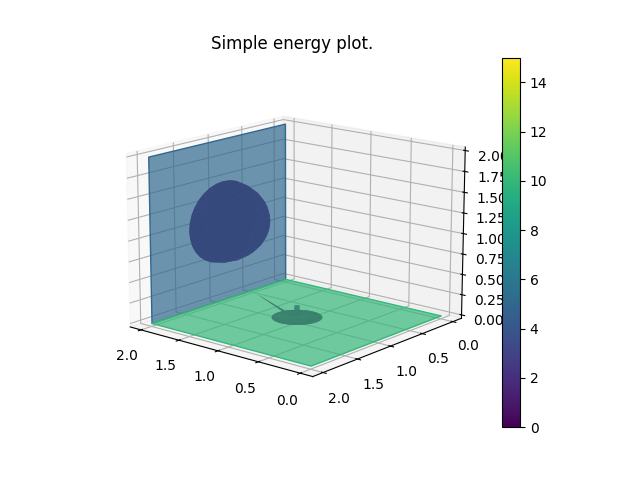

In [14]:
# clip data for better visualization
brdf_array.freq[brdf_array.freq > 1] = 1
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
sp.plot.polygons_3d(
    edge_points=boundaries,
    energy=energy,
    ax=ax,
    v_min=0,
    v_max=15,
    colorbar=True,
    brdf_points=brdf_out,  # equal to brdf_in
    brdf_data=brdf_array,
    scale_brdf=0.5,
)
plt.title("Simple energy plot.")
ax.view_init(elev=15, azim=130, roll=0)
plt.show()